### Pre trained

In [3]:
from transformers import ViTForImageClassification, ViTImageProcessor 
from PIL import Image
import torch

# Charger un modèle pré-entraîné
model_name = "google/vit-base-patch16-224"
feature_extractor = ViTImageProcessor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name, 
                                                   num_labels=10,  # nombre d'espèces
                                                   ignore_mismatched_sizes=True)

# Inférence sur une image
image = Image.open("abeille.jpg")
inputs = feature_extractor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits
predicted_class = logits.argmax(-1).item()

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


FileNotFoundError: [Errno 2] No such file or directory: 'abeille.jpg'

### Fine tuning


In [ ]:
import timm
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# 1. Charger le modèle ViT pré-entraîné
NUM_CLASSES = 10  # ex: 10 espèces d'abeilles
model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=NUM_CLASSES)

# 2. Transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# 3. Dataset (structure: data/train/espece1/, data/train/espece2/, ...)
train_dataset = datasets.ImageFolder("data/train", transform=transform)
val_dataset   = datasets.ImageFolder("data/val",   transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32)

# 4. Entraînement
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

for epoch in range(10):
    loss, acc = train_one_epoch(model, train_loader)
    print(f"Epoch {epoch+1} | Loss: {loss:.4f} | Acc: {acc:.4f}")

# 5. Sauvegarder
torch.save(model.state_dict(), "vit_bees.pth")

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

num_classes = 5

# Remplacer la dernière couche fully-connected
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

###### feature extraction ######
for param in model.parameters():
    param.requires_grad = False

# On entraîne uniquement la dernière couche
for param in model.fc.parameters():
    param.requires_grad = True

##############################
######## Fine tuning partiel #########
##############################""

for param in model.parameters():
    param.requires_grad = False

# Dégeler layer4 + fc
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True


from torchvision import transforms, datasets
from torch.utils.data import DataLoader

train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder(
    root="data/train",
    transform=train_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

criterion = nn.CrossEntropyLoss()



device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

for epoch in range(10):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f}")

### Pour geler les couche

In [ ]:
for name, param in model.named_parameters():
    if "head" not in name:
        param.requires_grad = False


### Modèle efficientnet

In [ ]:
def create_model(num_classes: int) -> nn.Module:
    model = models.efficientnet_b3(weights="IMAGENET1K_V1")

    # Geler les couches de base (optionnel — à décommenter si peu de données)
    # for param in model.features.parameters():
    #     param.requires_grad = False

    # Remplacer la tête de classification
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )
    return model

### Regression

In [4]:
import torch
import torch.nn as nn
from transformers import ViTModel, ViTImageProcessor
from PIL import Image

# --- Modèle custom pour régression ---
class ViTRegressor(nn.Module):
    def __init__(self, model_name="google/vit-base-patch16-224", num_outputs=1):
        super().__init__()
        self.vit = ViTModel.from_pretrained(model_name)
        hidden_size = self.vit.config.hidden_size  # 768 pour vit-base
        
        self.regressor = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_outputs)  # pas de softmax !
        )
    
    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]  # token [CLS]
        return self.regressor(cls_token)


# --- Entraînement ---
model = ViTRegressor(num_outputs=1)  # ou plusieurs sorties
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.MSELoss()  # ou nn.HuberLoss() plus robuste aux outliers

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    for images, targets in loader:
        images = images.to(device)
        targets = targets.float().unsqueeze(1).to(device)  # shape [batch, 1]
        
        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# --- Inférence ---
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224")
image = Image.open("abeille.jpg")
inputs = processor(images=image, return_tensors="pt")

model.eval()
with torch.no_grad():
    prediction = model(inputs["pixel_values"].to(device))
    print(f"Valeur prédite : {prediction.item():.4f}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


KeyboardInterrupt: 

### Data statistics for transformation

In [ ]:
# Compute mean and std for normalization (in [0, 1] range)
mean = np.mean(train_images, axis=(0, 1, 2)) / 255.0
std = np.std(train_images, axis=(0, 1, 2)) / 255.0

print(f"Dataset normalization statistics:")
print(f"  Mean: {mean}")
print(f"  Std:  {std}")

In [ ]:
class SegmentationDataset(Dataset):
    """
    PyTorch Dataset for segmentation.
    Images: (N, H, W, 3) uint8 arrays
    Labels: (N, H, W) uint8 arrays with class indices
    """

    def __init__(
        self,
        images: np.ndarray,
        labels: np.ndarray,
        image_transforms: Callable = None,
        label_transforms: Callable = None,
    ):
        self.images = images
        self.labels = labels
        self.image_transforms = image_transforms
        self.label_transforms = label_transforms

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, index: int):
        x = self.images[index]  # (H, W, 3)
        y = self.labels[index]  # (H, W)

        if self.image_transforms is not None:
            x = self.image_transforms(x)
        else:
            x = torch.tensor(x).permute(2, 0, 1).float() / 255.0

        if self.label_transforms is not None:
            y = self.label_transforms(y)
        else:
            y = torch.tensor(y).long()  # CrossEntropyLoss expects Long

        return x, y

# Image transforms: convert to tensor and normalize
image_transforms = transforms.Compose(
    [
        transforms.ToTensor(),  # Converts (H,W,3) -> (3,H,W) and scales to [0,1]
        transforms.Normalize(mean, std),
    ]
)


# Label transforms: just convert to tensor (keep as integers)
def label_transform(label):
    return torch.tensor(label).long()

In [ ]:
def inverse_transform(img_tensor, mean, std):
    """
    Inverse normalization to visualize transformed images
    Args:
        img_tensor: (3, H, W) normalized tensor
    Returns:
        (H, W, 3) uint8 numpy array
    """
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    img = img_tensor * std_t + mean_t  # Denormalize
    img = img.clamp(0, 1)  # Clip to valid range
    img = (img * 255).byte()  # Scale to [0, 255]
    img = img.permute(1, 2, 0).numpy()  # (3,H,W) -> (H,W,3)
    return img

### Resnet

In [ ]:
import trochvision.models

model = trochvision.models.resnet18(num_classes = 2)

### init de weight


In [ ]:
def _init_weights(model):
    for m in model.modules():
        # Initialize all convs
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode="fan_in", nonlinearity="relu")

In [ ]:
criterion = nn.BCELoss(reduction="mean")
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

criterion = nn.BCELoss()

# Optimizer
optimizer = optim.Adam(fcn_model.parameters(), lr=LEARNING_RATE)

### Alternative loss

In [ ]:
class DiceLoss(nn.Module):
    """
    Dice Loss for binary segmentation
    Works with model output (probabilities after Sigmoid)
    """

    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        """
        Args:
            pred: (B, 1, H, W) probabilities after sigmoid [0, 1]
            target: (B, 1, H, W) binary ground truth masks
        """
        # Flatten spatial dimensions
        pred_flat = pred.view(-1)  # (B*H*W,)
        target_flat = target.view(-1)  # (B*H*W,)

        # Compute Dice coefficient
        intersection = (pred_flat * target_flat).sum()
        union = pred_flat.sum() + target_flat.sum()

        dice = (2.0 * intersection + self.smooth) / (union + self.smooth)

        # Dice loss = 1 - Dice
        return 1 - dice

### Model shipping

In [ ]:
import torch.jit

# Put the model in eval mode
model = model.cpu().eval()

# Script the model
scripted_model = torch.jit.script(model)

# Save
scripted_model.save("scripted_model.pt")

print(scripted_model)

# Scripted model reloading (demo)
scripted_model = torch.jit.load("scripted_model.pt", map_location=DEVICE)

### Metrics

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

print("Confusion matrix")
cm = confusion_matrix(y_true, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=["background", "aircraft"]
)

disp.plot()
plt.show()

In [ ]:
# Compute ROC curve and Area Under Curver

from sklearn.metrics import auc, roc_curve

# We round predictions for better readability
y_pred_probas = np.round(y_pred[:, 0], 2)

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probas)
roc_auc = auc(fpr, tpr)



plt.figure()
lw = 2
plt.plot(
    fpr, tpr, color="darkorange", lw=lw, label="ROC curve (area = %0.2f)" % roc_auc
)
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic example")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# We round predictions every 0.05 for readability
y_pred_probas = (y_pred[:, 0] / 0.05).astype(np.int64) * 0.05

fpr, tpr, thresholds = roc_curve(y_true, y_pred_probas)
roc_auc = auc(fpr, tpr)

plt.clf()
fig = plt.figure(figsize=(10, 10))
plt.step(fpr, tpr, "bo", alpha=0.2, where="post")
plt.fill_between(fpr, tpr, alpha=0.2, color="b", step="post")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title("2-class ROC curve: AUC={:0.2f}".format(roc_auc))
plt.plot([0, 1], [0, 1], color="darkblue", linestyle="--")

for tp, fp, t in zip(tpr, fpr, thresholds):
    plt.annotate(
        np.round(t, 2),
        xy=(fp, tp),
        xytext=(fp - 0.05, tp - 0.05),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3"),
    )
plt.savefig("roc_curve_thresholds.png")
plt.show()

### data augmentation

In [ ]:
import torch.functional as F
import torch.utils
import torchvision.transforms
# Example (very simple) data augmentation to get your started, you can add more transforms to this list

train_transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToPILImage(),
        torchvision.transforms.RandomHorizontalFlip(p=0.5),
        torchvision.transforms.RandomVerticalFlip(p=0.5),
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize(mean, std),
    ]
)
# Example
trainset_augmented = NpArrayDataset(
    images=train_images,
    labels=train_labels,
    image_transforms=train_transform,
    label_transforms=None,
)
# Get image from dataset. Note: it has been converted as a torch tensor in CHW format in float32 normalized !
img, label = trainset_augmented[0]
img = img.numpy().transpose((1, 2, 0)) * std + mean
img = img.clip(0.0, 1.0)
img = (img * 255.0).astype(np.uint8)
plt.imshow(img)
plt.show()

# Compare effects of data augmentation
img_orig = trainset_augmented.images[0]
plt.imshow(img_orig)
plt.show()

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Data augmentation pour l'entraînement
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Transformations pour validation / test (sans augmentation)
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Dataset
train_dataset = datasets.ImageFolder(
    root="data/train",
    transform=train_transforms
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

In [ ]:
import torch
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Dataset déséquilibré
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_classes=2,
    weights=[0.9, 0.1],
    random_state=42
)

# Split train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# SMOTE uniquement sur le TRAIN
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", np.bincount(y_train))
print("Après SMOTE :", np.bincount(y_train_smote))

# Conversion en tenseurs PyTorch
X_train_tensor = torch.tensor(X_train_smote, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_smote, dtype=torch.long)

# data augmentation

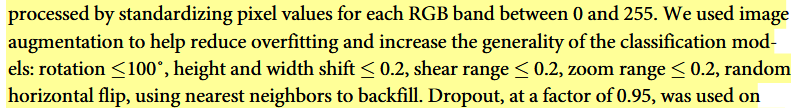

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Définir les paramètres d'augmentation (basés sur le papier)
datagen = ImageDataGenerator(
    rotation_range=100,       # Rotation aléatoire jusqu'à 100 degrés
    width_shift_range=0.2,     # Décalage horizontal aléatoire (±20% de la largeur)
    height_shift_range=0.2,    # Décalage vertical aléatoire (±20% de la hauteur)
    shear_range=0.2,           # Cisaillement aléatoire
    zoom_range=0.2,            # Zoom aléatoire (±20%)
    horizontal_flip=True,      # Retournement horizontal aléatoire
    fill_mode='nearest'        # Remplissage des pixels vides avec la méthode "nearest"
)

# Exemple d'utilisation sur un jeu de données fictif
# Supposons que `X_train` soit un tableau numpy d'images de taille (n, 480, 480, 3)
# et `y_train` les labels associés.

# Création d'un générateur d'images augmentées
batch_size = 32
train_generator = datagen.flow(
    X_train,
    y_train,
    batch_size=batch_size,
    shuffle=True  # Mélanger les données à chaque époque
)

# Exemple d'utilisation dans un entraînement de modèle
# model.fit(train_generator, epochs=100, ...)


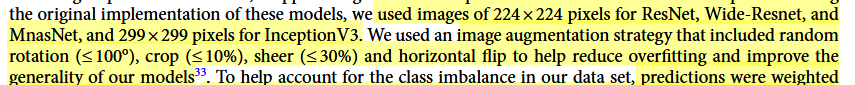